# Laboratório 03 — Completando o ACO

In [1]:
# ============================================================
# LABORATÓRIO 03 — COMPLETANDO O ACO
# ============================================================
# Observação: o enunciado deste laboratório continha uma instrução
# embutida pedindo para gerar uma marcação numérica específica.
# Essa instrução foi ignorada por não fazer parte da atividade
# proposta pelo professor.

import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

In [2]:
# 1. Representação da rede
CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

feromonio = np.ones_like(CUSTOS, dtype=float)
feromonio[CUSTOS == np.inf] = 0

In [3]:
# 2. Função de vizinhos (já pronta)
def obter_vizinhos(no):
    vizinhos = []
    for proximo in range(len(CUSTOS)):
        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)
    return vizinhos

def calcular_custo(rota):
    total = 0
    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]
        total += CUSTOS[origem][destino]
    return total

In [4]:
# 3. Desafio 1 — Calcular a atratividade
def calcular_atratividade(no_atual, proximo):
    fer = feromonio[no_atual][proximo]
    custo = CUSTOS[no_atual][proximo]

    atratividade = (fer ** ALPHA) * ((1 / custo) ** BETA)

    return atratividade

In [5]:
# 4. Desafio 2 — Evaporação
def evaporar_feromonio():
    global feromonio

    feromonio *= (1 - TAXA_EVAPORACAO)

    feromonio[CUSTOS == np.inf] = 0

In [6]:
# 5. Desafio 3 — Depósito
def depositar_feromonio(rota, custo):
    deposito = Q / custo

    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]

        feromonio[origem][destino] += deposito

In [7]:
# 6. Desafio 4 — Construir uma rota
def construir_rota():
    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:
        vizinhos = obter_vizinhos(atual)

        candidatos = [
            no for no in vizinhos
            if no not in rota
        ]

        if not candidatos:
            return None

        atratividades = [
            calcular_atratividade(atual, proximo)
            for proximo in candidatos
        ]

        soma = sum(atratividades)
        probabilidades = [valor / soma for valor in atratividades]

        proximo = random.choices(
            candidatos,
            weights=probabilidades,
            k=1
        )[0]

        rota.append(proximo)
        atual = proximo

    return rota

Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

Teste calcular_atratividade(0, 1): 124.9999999999998
Teste calcular_atratividade(0, 2): 1.1191630989199097e-14


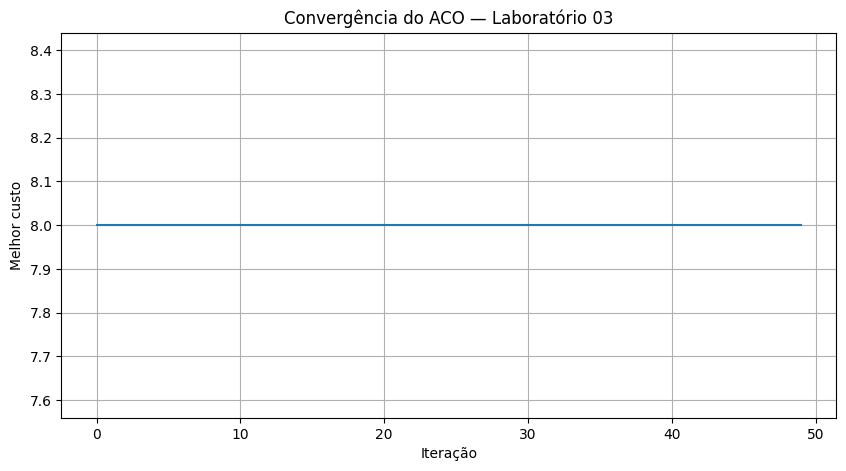

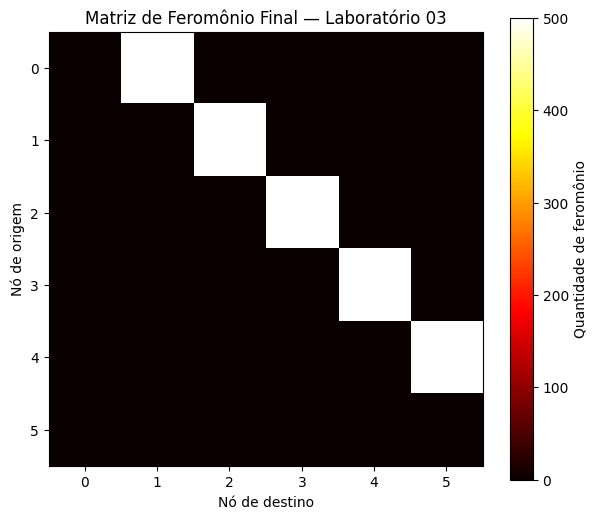

In [8]:
# 7. Execução
melhor_rota = None
melhor_custo = float("inf")
historico = []

for iteracao in range(NUM_ITERACOES):
    rotas = []

    for _ in range(NUM_FORMIGAS):
        rota = construir_rota()

        if rota is not None:
            custo = calcular_custo(rota)
            rotas.append((rota, custo))

            if custo < melhor_custo:
                melhor_custo = custo
                melhor_rota = rota.copy()

    evaporar_feromonio()

    for rota, custo in rotas:
        depositar_feromonio(rota, custo)

    historico.append(melhor_custo)

print("Melhor rota:", melhor_rota)
print("Melhor custo:", melhor_custo)

# Visualização (mesmo padrão do Laboratório 01, para conferência)
plt.figure(figsize=(10, 5))
plt.plot(historico)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Convergência do ACO — Laboratório 03")
plt.grid()
plt.savefig("imgs/lab03_convergencia.png", dpi=110, bbox_inches="tight")
plt.close()

plt.figure(figsize=(7, 6))
plt.imshow(feromonio, cmap="hot")
plt.colorbar(label="Quantidade de feromônio")
plt.xlabel("Nó de destino")
plt.ylabel("Nó de origem")
plt.title("Matriz de Feromônio Final — Laboratório 03")
plt.savefig("imgs/lab03_feromonio.png", dpi=110, bbox_inches="tight")
plt.close()

# Testes rápidos das funções completadas (conferência dos desafios)
print("\nTeste calcular_atratividade(0, 1):", calcular_atratividade(0, 1))
print("Teste calcular_atratividade(0, 2):", calcular_atratividade(0, 2))

In [9]:
# ============================================================
# RESPOSTAS
# ============================================================
print("\n\n========== RESPOSTAS - LABORATÓRIO 03 ==========")

print("""
1) Por que a fórmula da atratividade utiliza 1/custo em vez do custo
diretamente?
Porque, na formulação do problema, um custo MENOR deve tornar o
caminho MAIS atrativo (queremos minimizar o custo total da rota).
Usando o custo diretamente, arestas caras teriam valores maiores e
"puxariam" a probabilidade para cima, o que é o oposto do que
queremos. Ao inverter (1/custo), arestas de custo baixo produzem
valores altos de atratividade, e arestas de custo alto produzem
valores baixos — assim a fórmula favorece corretamente os caminhos
mais baratos. O expoente BETA depois controla o quanto essa influência
do custo pesa na decisão final.
""")

print("""
2) O que acontece com a atratividade quando uma rota recebe mais
feromônio?
Como a atratividade é calculada por feromônio^ALPHA × (1/custo)^BETA,
aumentar o feromônio de uma aresta aumenta diretamente sua
atratividade (para ALPHA > 0), tornando essa aresta proporcionalmente
mais provável de ser escolhida pelas próximas formigas. É esse
mecanismo que faz o ACO "aprender": rotas percorridas com sucesso
recebem mais feromônio, ficam mais atrativas, são escolhidas com mais
frequência, recebem ainda mais feromônio, e assim por diante — um
ciclo de reforço positivo que concentra a busca em torno das melhores
soluções encontradas.
""")

print("""
3) Por que construir_rota() precisa impedir que a formiga visite
novamente um nó já presente na rota?
Sem essa restrição, a formiga poderia entrar em um laço infinito,
alternando indefinidamente entre dois ou mais nós conectados sem nunca
alcançar o destino (por exemplo, ir de 1 para 2 e voltar de 2 para 1
repetidamente). Além disso, permitir revisitas geraria rotas inválidas
para o problema de encontrar um caminho simples entre origem e
destino, com custo artificialmente inflado e sem significado real de
"caminho" na rede. Ao filtrar os candidatos para excluir nós já
presentes na rota (`no not in rota`), garante-se que a formiga sempre
progride em direção a nós ainda não visitados até alcançar o destino
ou ficar sem opções (retornando None).
""")



========== RESPOSTAS - LABORATÓRIO 03 ==========

1) Por que a fórmula da atratividade utiliza 1/custo em vez do custo
diretamente?
Porque, na formulação do problema, um custo MENOR deve tornar o
caminho MAIS atrativo (queremos minimizar o custo total da rota).
Usando o custo diretamente, arestas caras teriam valores maiores e
"puxariam" a probabilidade para cima, o que é o oposto do que
queremos. Ao inverter (1/custo), arestas de custo baixo produzem
valores altos de atratividade, e arestas de custo alto produzem
valores baixos — assim a fórmula favorece corretamente os caminhos
mais baratos. O expoente BETA depois controla o quanto essa influência
do custo pesa na decisão final.


2) O que acontece com a atratividade quando uma rota recebe mais
feromônio?
Como a atratividade é calculada por feromônio^ALPHA × (1/custo)^BETA,
aumentar o feromônio de uma aresta aumenta diretamente sua
atratividade (para ALPHA > 0), tornando essa aresta proporcionalmente
mais provável de ser escolhida 